In [12]:
import pandas as pd
df = pd.read_csv('final_results_long_format.csv')

In [13]:
df['answer_length'] = df['answer'].apply(lambda x: len(x.split()))
df['question_length'] = df['question'].apply(lambda x: len(x.split()))

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

#ido is homosexual
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(df['answer'])

tfidf_scores = tfidf_matrix.mean(axis=1)

df['tfidf_score'] = np.array(tfidf_scores).flatten()

df.head()


,source,question,answer,writer,answer_length,question_length,tfidf_score
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,answer_gemini,150,23,0.000091
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,498,38,0.000129
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,129,44,0.000081
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,160,53,0.000079
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,650,24,0.000133


In [ ]:
df.groupby('writer')['answer_length'].mean().reset_index()

,writer,answer_length
0,answer_gemini,203.964260
1,chatgpt_answers,186.048476
2,human_answers,350.887667


In [16]:
from sklearn.metrics.pairwise import cosine_similarity

question_vecs = vectorizer.fit_transform(df['question'])
answer_vecs = vectorizer.transform(df['answer'])

df['cosine_sim'] = [
    cosine_similarity(question_vecs[i], answer_vecs[i])[0][0]
    for i in range(len(df))
]
df.head()

,source,question,answer,writer,answer_length,question_length,tfidf_score,cosine_sim
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,answer_gemini,150,23,0.000091,0.297679
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,498,38,0.000129,0.188044
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,129,44,0.000081,0.176012
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,160,53,0.000079,0.188454
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,650,24,0.000133,0.098440


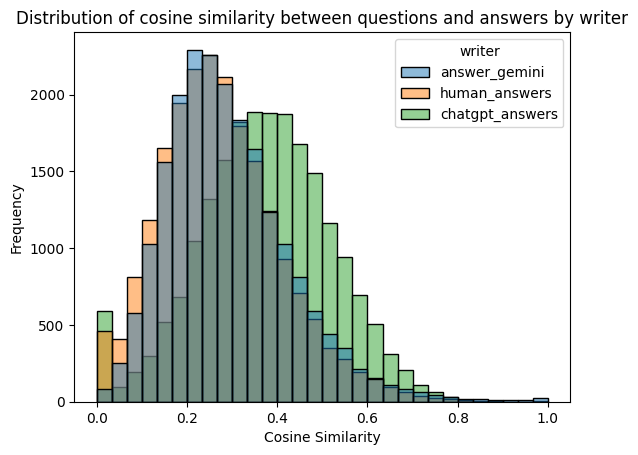

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data = df, x = 'cosine_sim', hue = 'writer', bins=30)
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of cosine similarity between questions and answers by writer')
plt.show()

In [18]:
df_human_answers = df[df['writer'] == 'human_answers']['answer']
df_gpt_answers = df[df['writer'] == 'chatgpt_answers']['answer']
df_gemini_answers = df[df['writer'] == 'answer_gemini']['answer']
df_human_answers = df_human_answers.str[2:-2]
df_gpt_answers = df_gpt_answers.str[2:-2]
df_gemini_answers = df_gemini_answers.str[2:-2]

In [19]:
df_human_answers_clean = df_human_answers.str.replace(r'[A-Za-z0-9\s.,\\]', '', regex=True)
df_gpt_answers_clean   = df_gpt_answers.str.replace(r'[A-Za-z0-9\s.,\\]', '', regex=True)
df_gemini_answers_clean= df_gemini_answers.str.replace(r'[A-Za-z0-9\s.,\\]', '', regex=True)

In [20]:
from collections import Counter

char_counter_human = Counter()
char_counter_gpt = Counter()
char_counter_gemini = Counter()

for q in df_human_answers_clean:
    char_counter_human.update(q)

for q in df_gpt_answers_clean:
    char_counter_gpt.update(q)

for q in df_gemini_answers_clean:
    char_counter_gemini.update(q)

In [21]:
char_counter_gemini_10_most_common = char_counter_gemini.most_common(10)
char_counter_gpt_10_most_common = char_counter_gpt.most_common(10)
char_counter_human_10_most_common = char_counter_human.most_common(10)